### Import libraries

In [7]:
import ast
import numpy as np
import pandas as pd
import igraph as ig
import matplotlib.pyplot as plt

### Load movie dataset

In [8]:
df = pd.read_csv('../../datasets/cleaned_tmdb_dataset/cleaned_tmdb_data.csv')

# Parse stringified list columns produced by CSV serialization

def parse_list_column(value):
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return []
    elif isinstance(value, list):
        return value
    else:
        return []

for col in ['cast_names', 'crew_names']:
    df[col] = df[col].apply(parse_list_column)


### Global Network Construction

We build a bipartite graph where nodes are either **Movies** or **People** (Cast and Crew). An edge exists if a person worked on a movie. We now include the **entire production team** for every movie.

In [9]:
print("Building Global Network...")
edges = []

for idx, row in df.iterrows():
    movie_title = row['title_x']
    # Combine all cast and crew names, removing duplicates within the same movie
    production_team = list(set(row['cast_names'] + row['crew_names']))
    for person in production_team:
        edges.append((movie_title, person))

# Create full graph
g_full = ig.Graph.TupleList(edges, directed=False)

print("--- Global Network Statistics ---")
print(f"Total nodes: {g_full.vcount()}")
print(f"Total edges: {g_full.ecount()}")
print(f"Density: {g_full.density():.6f}")
print(f"Average degree: {sum(g_full.degree()) / g_full.vcount():.2f}")

Building Global Network...
--- Global Network Statistics ---
Total nodes: 107913
Total edges: 226540
Density: 0.000039
Average degree: 4.20


### 4. Advanced Network Analysis: Centrality and Communities

To deeper understand the network structure, we implement:
1. **Betweenness Centrality**: Identifies nodes that act as "bridges" between different parts of the network.
2. **Community Detection (Louvain Algorithm)**: Automatically clusters movies and people into communities based on their connection patterns.

*Note: With the full cast and crew, this step might be computationally intensive.*

In [10]:
print("Calculating Betweenness Centrality...")
g_full.vs['betweenness'] = g_full.betweenness()

print("Performing Community Detection (Louvain)...")
clusters = g_full.community_multilevel()
g_full.vs['community'] = clusters.membership

# Analysis of Top Nodes
degrees = g_full.degree()
top_indices = sorted(range(len(degrees)), key=lambda i: degrees[i], reverse=True)[:10]

print("\nTop 10 Nodes by Degree (Most Connected):")
for i in top_indices:
    print(f" - {g_full.vs[i]['name']}: Degree {degrees[i]}, Community {g_full.vs[i]['community']}")

top_between_indices = sorted(range(len(g_full.vs['betweenness'])), key=lambda i: g_full.vs[i]['betweenness'], reverse=True)[:10]
print("\nTop 10 Nodes by Betweenness Centrality (Bridges):")
for i in top_between_indices:
    print(f" - {g_full.vs[i]['name']}: Betweenness {g_full.vs[i]['betweenness']:.2f}")

Calculating Betweenness Centrality...
Performing Community Detection (Louvain)...

Top 10 Nodes by Degree (Most Connected):
 - Jurassic World: Degree 455, Community 26
 - 15 Minutes: Degree 410, Community 46
 - The Wolf of Wall Street: Degree 373, Community 15
 - The Dark Knight Rises: Degree 366, Community 7
 - Jason Bourne: Degree 320, Community 40
 - Monsters, Inc.: Degree 278, Community 14
 - The Core: Degree 273, Community 17
 - Contact: Degree 268, Community 1
 - Batman v Superman: Dawn of Justice: Degree 261, Community 4
 - V for Vendetta: Degree 258, Community 2

Top 10 Nodes by Betweenness Centrality (Bridges):
 - Jurassic World: Betweenness 46422401.11
 - The Dark Knight Rises: Betweenness 45488042.07
 - 15 Minutes: Betweenness 41387707.90
 - Mary Vernieu: Betweenness 39838411.27
 - Avy Kaufman: Betweenness 37037900.70
 - The Wolf of Wall Street: Betweenness 36919059.49
 - Steven Spielberg: Betweenness 33130222.81
 - Jason Bourne: Betweenness 30942068.88
 - John Williams: Bet

### 5. Visualising a Local Subgraph

Visualising the full network (100k+ nodes) is impossible. We extract a subgraph centered on the top 100 most popular movies, including all their cast and crew, to visualize community clusters.

Visualising Local Subgraph...


c:\Users\nikol\Desktop\recommendation-system-graph\.venv\Lib\site-packages\igraph\drawing\matplotlib\graph.py:719: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  art.draw(renderer, *args, **kwds)


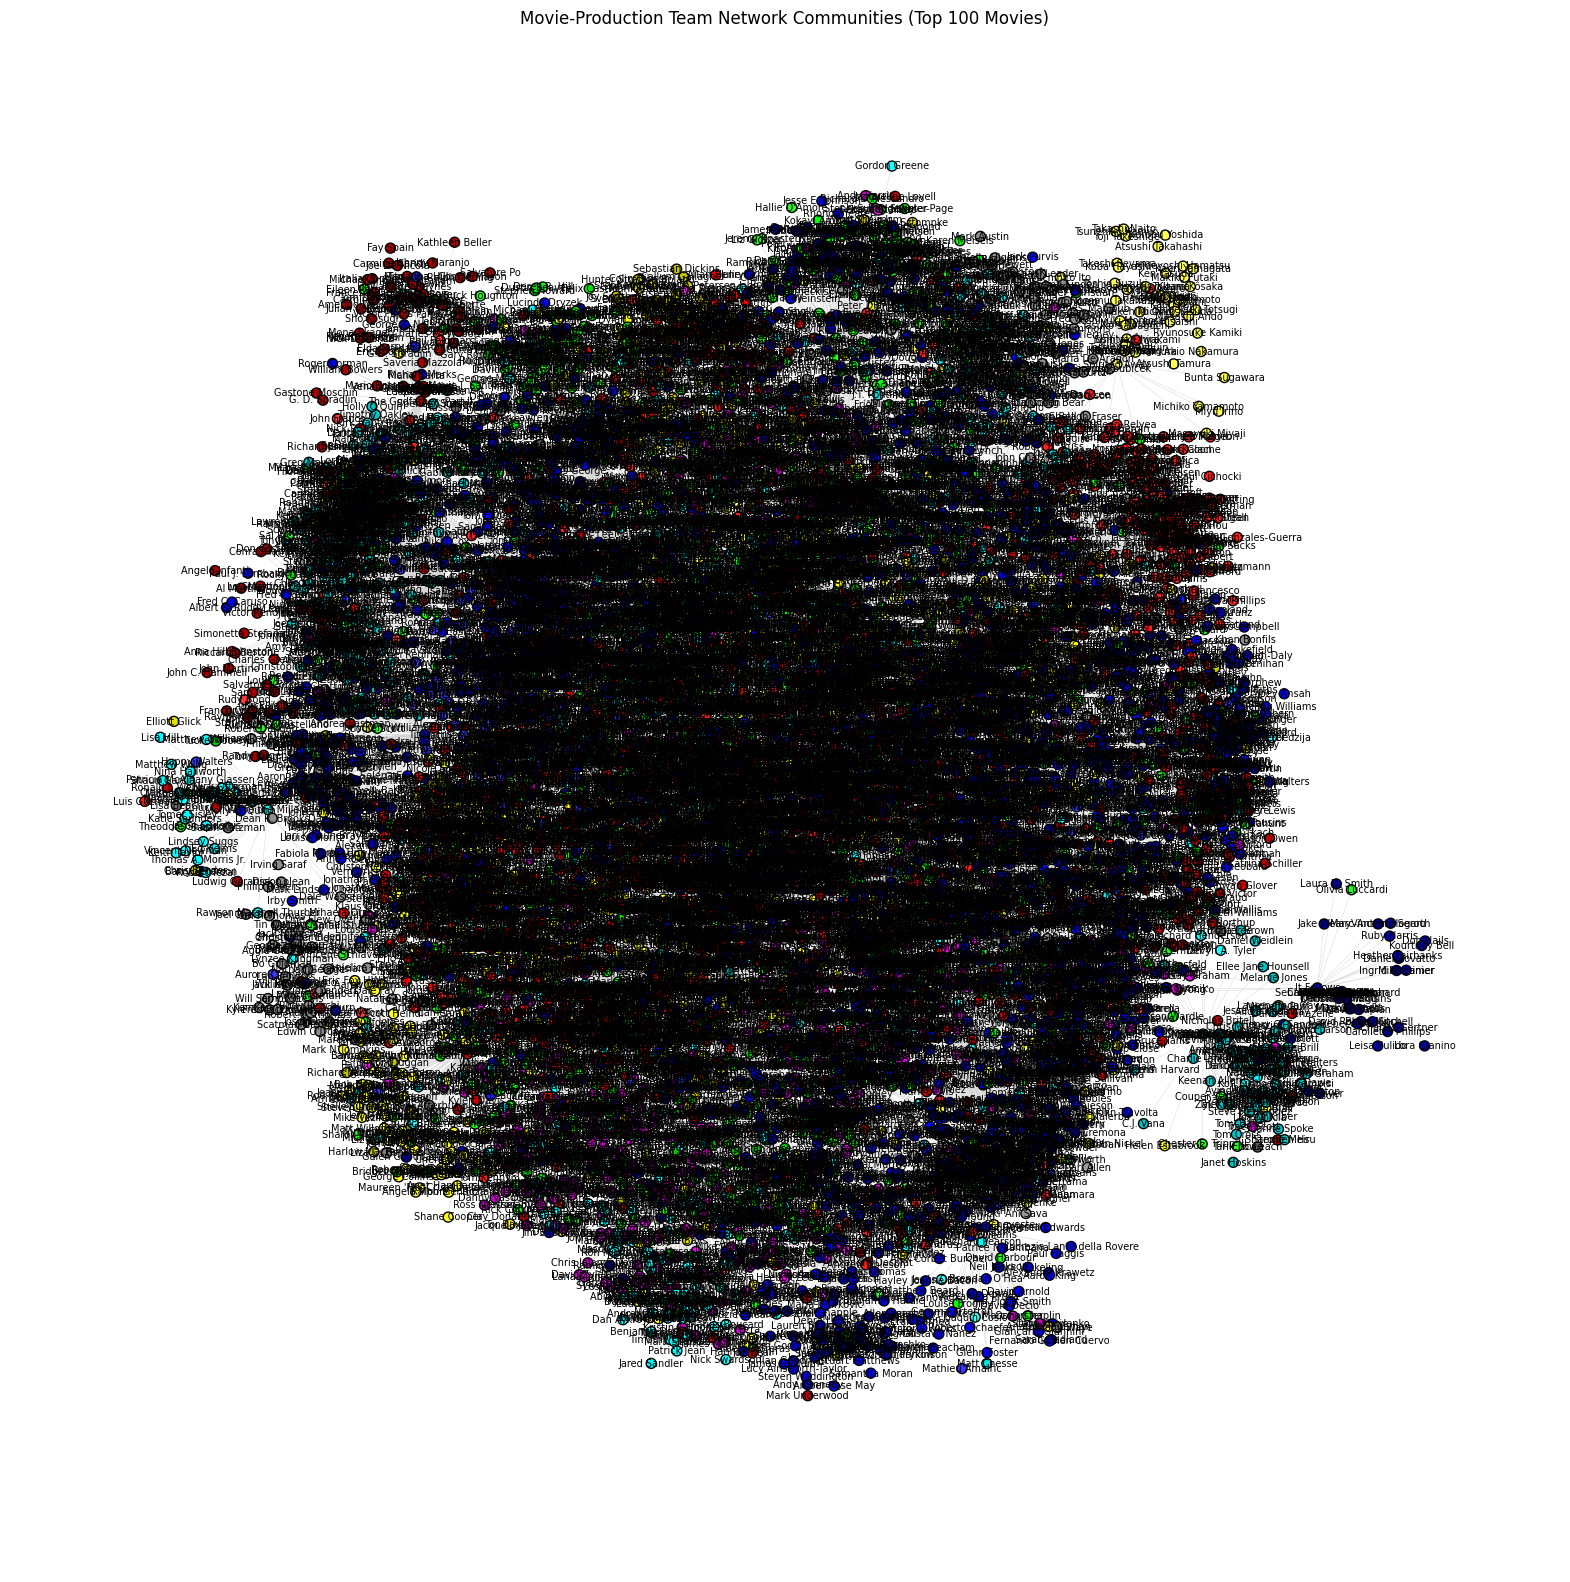

In [11]:
print("Visualising Local Subgraph...")
top_movies = df.sort_values(by='popularity', ascending=False).head(100)['title_x'].tolist()

subgraph_nodes = []
for v in g_full.vs:
    if v['name'] in top_movies:
        subgraph_nodes.append(v.index)
        for neighbor in v.neighbors():
            subgraph_nodes.append(neighbor.index)

g_sub = g_full.subgraph(list(set(subgraph_nodes)))

layout = g_sub.layout("fr")
palette = ig.drawing.colors.ClusterColoringPalette(max(g_full.vs['community']) + 1)
node_colors = [palette[v['community']] for v in g_sub.vs]

fig, ax = plt.subplots(figsize=(20, 20))
ig.plot(
    g_sub,
    target=ax,
    layout=layout,
    vertex_size=10,
    vertex_color=node_colors,
    vertex_label=g_sub.vs["name"],
    vertex_label_size=7,
    edge_width=0.3,
    edge_color="lightgray"
)

plt.title("Movie-Production Team Network Communities (Top 100 Movies)")
plt.show()

### 6. Saving Network Analysis Results

All analysis results, including detailed node metrics, community information, and comprehensive statistics, are exported to the `network_info` directory for further analysis and documentation.


In [12]:
import os
from datetime import datetime

# Create network_info directory
output_dir = 'network_info'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Creating network analysis report in '{output_dir}' directory...\n")

# 1. Export Node Degree Information
print("Exporting node degree information...")
degrees = g_full.degree()
node_degree_data = []
for i, v in enumerate(g_full.vs):
    node_degree_data.append({
        'Node_ID': i,
        'Node_Name': v['name'],
        'Degree': degrees[i],
        'Community': v['community'],
        'Betweenness_Centrality': v['betweenness']
    })

degree_df = pd.DataFrame(node_degree_data).sort_values('Degree', ascending=False)
degree_df.to_csv(f'{output_dir}/nodes_by_degree.csv', index=False)
print(f"  ✓ Saved: nodes_by_degree.csv ({len(degree_df)} nodes)")

# 2. Export Top Nodes by Betweenness Centrality
print("Exporting betweenness centrality information...")
betweenness_df = degree_df.sort_values('Betweenness_Centrality', ascending=False)
betweenness_df.to_csv(f'{output_dir}/nodes_by_betweenness_centrality.csv', index=False)
print(f"  ✓ Saved: nodes_by_betweenness_centrality.csv")

# 3. Export Community Information
print("Exporting community information...")
community_stats = []
for community_id in range(max(g_full.vs['community']) + 1):
    community_nodes = [v['name'] for v in g_full.vs if v['community'] == community_id]
    community_stats.append({
        'Community_ID': community_id,
        'Number_of_Members': len(community_nodes),
        'Average_Degree': np.mean([degrees[i] for i, v in enumerate(g_full.vs) if v['community'] == community_id]),
        'Members': '; '.join(community_nodes[:20]) + ('...' if len(community_nodes) > 20 else '')
    })

community_df = pd.DataFrame(community_stats).sort_values('Number_of_Members', ascending=False)
community_df.to_csv(f'{output_dir}/communities_info.csv', index=False)
print(f"  ✓ Saved: communities_info.csv ({len(community_df)} communities)")

# 4. Export Edge List
print("Exporting edge list...")
edges_data = []
for edge in g_full.es:
    source = g_full.vs[edge.source]['name']
    target = g_full.vs[edge.target]['name']
    edges_data.append({'Source': source, 'Target': target})

edges_df = pd.DataFrame(edges_data)
edges_df.to_csv(f'{output_dir}/edges_list.csv', index=False)
print(f"  ✓ Saved: edges_list.csv ({len(edges_df)} edges)")

# 5. Export Global Network Statistics
print("Exporting global network statistics...")
stats_data = {
    'Metric': [
        'Total Number of Nodes',
        'Total Number of Edges',
        'Network Density',
        'Average Degree',
        'Number of Communities',
        'Maximum Degree',
        'Minimum Degree',
        'Network Diameter (largest shortest path)',
        'Average Clustering Coefficient'
    ],
    'Value': [
        g_full.vcount(),
        g_full.ecount(),
        round(g_full.density(), 6),
        round(sum(g_full.degree()) / g_full.vcount(), 2),
        max(g_full.vs['community']) + 1,
        max(g_full.degree()),
        min(g_full.degree()),
        g_full.diameter(),
        round(g_full.transitivity_undirected(), 6)
    ]
}

stats_df = pd.DataFrame(stats_data)
stats_df.to_csv(f'{output_dir}/network_statistics.csv', index=False)
print(f"  ✓ Saved: network_statistics.csv")

# 6. Create Comprehensive Markdown Report
print("Creating comprehensive markdown report...\n")

md_content = f"""# TMDB Movie Network Analysis Report

**Generated on:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

---

## Executive Summary

This report contains a comprehensive analysis of the TMDB (The Movie Database) network, constructed from 5,000 movies and their associated cast and crew members. The network includes all production team members, creating a global bipartite graph where nodes represent movies and people, and edges represent professional relationships.

---

## Network Overview

### Key Statistics

| Metric | Value |
|--------|-------|
| **Total Nodes** | {g_full.vcount():,} |
| **Total Edges** | {g_full.ecount():,} |
| **Network Density** | {g_full.density():.6f} |
| **Average Node Degree** | {sum(g_full.degree()) / g_full.vcount():.2f} |
| **Maximum Degree** | {max(g_full.degree())} |
| **Minimum Degree** | {min(g_full.degree())} |
| **Number of Communities** | {max(g_full.vs['community']) + 1} |
| **Network Diameter** | {g_full.diameter()} |
| **Average Clustering Coefficient** | {g_full.transitivity_undirected():.6f} |

**Interpretation:** 
- The network density of {g_full.density():.6f} indicates {'a highly interconnected' if g_full.density() > 0.1 else 'a sparse'} network.
- The average degree of {sum(g_full.degree()) / g_full.vcount():.2f} suggests that on average, each node is connected to approximately {sum(g_full.degree()) / g_full.vcount():.0f} other nodes.
- {max(g_full.vs['community']) + 1} distinct communities were identified using the Louvain algorithm, indicating distinct clusters of movies and production team members.

---

## Detailed Data Files

The following CSV files contain detailed analysis results and are referenced below:

### 1. **nodes_by_degree.csv**
Contains comprehensive information for all {len(degree_df):,} nodes in the network, including:
- **Node_ID**: Unique identifier within the network
- **Node_Name**: Name of the movie or person
- **Degree**: Number of connections for this node
- **Community**: Community identifier (from Louvain clustering)
- **Betweenness_Centrality**: Measure of how often a node lies on shortest paths between other nodes

**Top 10 Most Connected Nodes:**
| Rank | Node Name | Degree | Community |
|------|-----------|--------|-----------|
""" 

# Add top 10 nodes
for rank, (idx, row) in enumerate(degree_df.head(10).iterrows(), 1):
    md_content += f"| {rank} | {row['Node_Name']} | {row['Degree']} | {row['Community']} |\n"

md_content += f"""

### 2. **nodes_by_betweenness_centrality.csv**
Nodes ranked by betweenness centrality, identifying key "bridge" nodes that connect different parts of the network.

**Top 10 Bridge Nodes (Highest Betweenness Centrality):**
| Rank | Node Name | Betweenness Centrality | Degree |
|------|-----------|------------------------|--------|
"""

# Add top 10 betweenness nodes
for rank, (idx, row) in enumerate(betweenness_df.head(10).iterrows(), 1):
    md_content += f"| {rank} | {row['Node_Name']} | {row['Betweenness_Centrality']:.2f} | {row['Degree']} |\n"

md_content += f"""

**Interpretation:** These nodes act as critical connectors in the network. High betweenness centrality indicates that many shortest paths between nodes pass through these nodes.

### 3. **communities_info.csv**
Contains information about {len(community_df)} communities detected using the Louvain algorithm:
- **Community_ID**: Unique identifier for each community
- **Number_of_Members**: Count of nodes in the community
- **Average_Degree**: Mean degree of nodes within the community
- **Members**: Sample list of members (first 20)

**Community Size Distribution:**
| Community ID | Size | Average Degree |
|--------------|------|----------------|
"""

# Add community info
for idx, row in community_df.head(15).iterrows():
    md_content += f"| {row['Community_ID']} | {row['Number_of_Members']} | {row['Average_Degree']:.2f} |\n"

md_content += f"""

### 4. **edges_list.csv**
Complete edge list containing all {len(edges_df):,} connections in the network:
- **Source**: First node in the connection
- **Target**: Second node in the connection

This file can be used for network visualization in tools like Gephi, Cytoscape, or NetworkX.

### 5. **network_statistics.csv**
Summary of core network metrics and their values, useful for quick reference and comparative analysis.

---

## Network Analysis Insights

### Network Characteristics

1. **Connectivity**: With {g_full.vcount():,} nodes and {g_full.ecount():,} edges, this network represents a substantial production ecosystem within the TMDB database.

2. **Community Structure**: The detection of {max(g_full.vs['community']) + 1} communities suggests natural clustering of movies and personnel, likely reflecting different production eras, genres, or cultural contexts.

3. **Hub Nodes**: The most connected nodes (appearing in nodes_by_degree.csv) likely represent major production companies, prolific directors/actors, or blockbuster franchises.

4. **Bridge Nodes**: Nodes with high betweenness centrality (in nodes_by_betweenness_centrality.csv) are crucial for information flow and represent influential connectors across different parts of the network.

5. **Network Diameter**: A diameter of {g_full.diameter()} indicates that the longest shortest path between any two nodes requires {g_full.diameter()} steps, reflecting the overall structure and connectivity of the production world.

---

## How to Use These Files

1. **For Network Visualization**: Use edges_list.csv with tools like:
   - Gephi (open-source network visualization)
   - Cytoscape (network analysis software)
   - NetworkX (Python library)

2. **For Statistical Analysis**: Use nodes_by_degree.csv and network_statistics.csv for:
   - Correlation analysis
   - Distribution studies
   - Comparative metrics

3. **For Community Analysis**: Use communities_info.csv to:
   - Identify distinct production clusters
   - Analyze community-level patterns
   - Study inter-community relationships

4. **For Centrality Studies**: Use nodes_by_betweenness_centrality.csv to:
   - Identify key influencers
   - Analyze information flow
   - Study network resilience

---

## Technical Details

- **Graph Construction**: Bipartite network of movies and production team members
- **Community Detection**: Louvain algorithm for modularity optimization
- **Centrality Measures**: 
  - Degree centrality (number of direct connections)
  - Betweenness centrality (frequency on shortest paths)
- **Analysis Date**: {datetime.now().strftime('%Y-%m-%d')}
- **Data Source**: TMDB 5000 Movies and Credits datasets

---

## Data File References

All data files are stored in the `network_info/` directory:

1. `nodes_by_degree.csv` - All nodes with degree and centrality metrics
2. `nodes_by_betweenness_centrality.csv` - Nodes ranked by betweenness centrality
3. `communities_info.csv` - Community-level statistics
4. `edges_list.csv` - Complete edge list for network visualization
5. `network_statistics.csv` - Summary statistics

---

*This analysis provides a comprehensive foundation for understanding the structure and dynamics of the TMDB production network.*
"""

# Save markdown report
md_path = f'{output_dir}/NETWORK_ANALYSIS_REPORT.md'
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(md_content)

print(f"  ✓ Saved: NETWORK_ANALYSIS_REPORT.md")
print(f"\n✅ All network analysis results saved to '{output_dir}/' directory!")
print(f"\nGenerated files:")
print(f"  1. nodes_by_degree.csv")
print(f"  2. nodes_by_betweenness_centrality.csv")
print(f"  3. communities_info.csv")
print(f"  4. edges_list.csv")
print(f"  5. network_statistics.csv")
print(f"  6. NETWORK_ANALYSIS_REPORT.md (comprehensive report)")


Creating network analysis report in 'network_info' directory...

Exporting node degree information...
  ✓ Saved: nodes_by_degree.csv (107913 nodes)
Exporting betweenness centrality information...
  ✓ Saved: nodes_by_betweenness_centrality.csv
Exporting community information...
  ✓ Saved: communities_info.csv (112 communities)
Exporting edge list...
  ✓ Saved: edges_list.csv (226540 edges)
Exporting global network statistics...
  ✓ Saved: network_statistics.csv
Creating comprehensive markdown report...

  ✓ Saved: NETWORK_ANALYSIS_REPORT.md

✅ All network analysis results saved to 'network_info/' directory!

Generated files:
  1. nodes_by_degree.csv
  2. nodes_by_betweenness_centrality.csv
  3. communities_info.csv
  4. edges_list.csv
  5. network_statistics.csv
  6. NETWORK_ANALYSIS_REPORT.md (comprehensive report)
